# Overlapping Modular Centrality — ego-Facebook Network
## Replication Study: Ghalmane et al. (2019)

### Paper Reference
> Ghalmane, Z., Cherifi, C., Cherifi, H. & El Hassouni, M. **Centrality in Complex Networks with Overlapping Community Structure**. *Scientific Reports*, 9, 10133 (2019).  
> DOI: [10.1038/s41598-019-46507-y](https://doi.org/10.1038/s41598-019-46507-y)

---

## Dataset Information

| Property | Value |
|----------|-------|
| **Network** | ego-Facebook friendship network |
| **Source** | Leskovec & Mcauley (2012) |
| **Download** | [snap.stanford.edu/data/ego-Facebook](https://snap.stanford.edu/data/ego-Facebook.html) |
| **Expected Nodes** | ~4,039 |
| **Expected Edges** | ~88,234 |
| **Community Structure** | STRONG (μ ≈ 0.075) |
| **Expected Overlapping** | ~8.33% |

---

## Table of Contents

1. [Setup and Dependencies](#1-Setup-and-Dependencies)
2. [Load ego-Facebook Network](#2-Load-ego-Facebook-Network)
3. [Network Statistics](#3-Network-Statistics)
4. [Network Visualization](#4-Network-Visualization)
5. [Community Detection (SLPA)](#5-Community-Detection-SLPA)
6. [Network Decomposition](#6-Network-Decomposition)
7. [OMC Computation](#7-OMC-Computation)
8. [SIR Simulation](#8-SIR-Simulation)
9. [Results and Discussion](#9-Results-and-Discussion)

## 1. Setup and Dependencies

In [8]:
import subprocess, sys
print("Installing required packages...")
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                       'networkx', 'matplotlib', 'cdlib', 'numpy', 'scipy', 'pandas'])
print("Installation complete!")

Installing required packages...
Installation complete!


In [9]:
import random
import math
import warnings
import os
import time
from collections import defaultdict

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from cdlib import algorithms

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)

# Create output directories
os.makedirs('../figures', exist_ok=True)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## 2. Load ego-Facebook Network

In [10]:
def compute_epidemic_threshold(G):
    """Compute λ_th = <k> / (<k²> - <k>)."""
    degrees = [d for _, d in G.degree()]
    k1 = np.mean(degrees)
    k2 = np.mean([d**2 for d in degrees])
    return k1 / (k2 - k1) if k2 > k1 else 0

# Load network
print("Loading ego-Facebook network...")
print("Note: Download facebook_combined.txt from https://snap.stanford.edu/data/ego-Facebook.html")
start_time = time.time()

try:
    G = nx.read_edgelist('../data/ego-facebook/facebook_combined.txt', nodetype=int)
    G = G.subgraph(max(nx.connected_components(G), key=len)).copy()
    load_time = time.time() - start_time
    print(f"\n{'='*60}")
    print("ego-FACEBOOK NETWORK STATISTICS")
    print(f"{'='*60}")
    print(f"Loading time: {load_time:.2f}s")
    print(f"Nodes: {G.number_of_nodes():,} (expected: ~4,039)")
    print(f"Edges: {G.number_of_edges():,} (expected: ~88,234)")
    
    degrees = [d for _, d in G.degree()]
    print(f"\nDegree Statistics:")
    print(f"  Average degree: {np.mean(degrees):.2f}")
    print(f"  Max degree: {max(degrees)}")
    print(f"  Min degree: {min(degrees)}")
    print(f"  Median degree: {np.median(degrees):.1f}")
    print(f"\nNetwork Properties:")
    print(f"  Density: {nx.density(G):.4f}")
    print(f"  Average clustering: {nx.average_clustering(G):.4f}")
    
    lambda_th = compute_epidemic_threshold(G)
    print(f"\nEpidemic threshold λ_th = {lambda_th:.4f} (paper: 0.009)")
    print(f"{'='*60}")
    
except FileNotFoundError:
    print("\nERROR: facebook_combined.txt not found!")
    print("Please download from: https://snap.stanford.edu/data/ego-Facebook.html")
    print("Place the file in: ../data/ego-facebook/facebook_combined.txt")
    raise

Loading ego-Facebook network...
Note: Download facebook_combined.txt from https://snap.stanford.edu/data/ego-Facebook.html

ego-FACEBOOK NETWORK STATISTICS
Loading time: 0.67s
Nodes: 4,039 (expected: ~4,039)
Edges: 88,234 (expected: ~88,234)

Degree Statistics:
  Average degree: 43.69
  Max degree: 1045
  Min degree: 1
  Median degree: 25.0

Network Properties:
  Density: 0.0108
  Average clustering: 0.6055

Epidemic threshold λ_th = 0.0095 (paper: 0.009)


## 3. Network Statistics

In [11]:
# Detailed degree analysis
print("Computing detailed network statistics...")

# Degree distribution
degree_counts = nx.degree_histogram(G)
max_degree = max(degrees)

print(f"\nDegree Distribution:")
print(f"  Nodes with degree 1-10: {sum(degree_counts[1:11]) if len(degree_counts) > 10 else sum(degree_counts[1:])}")
print(f"  Nodes with degree 11-50: {sum(degree_counts[11:51]) if len(degree_counts) > 50 else 0}")
print(f"  Nodes with degree >50: {sum(degree_counts[51:]) if len(degree_counts) > 51 else 0}")

# Connected components
n_components = nx.number_connected_components(G)
print(f"\nConnected Components: {n_components}")

Computing detailed network statistics...

Degree Distribution:
  Nodes with degree 1-10: 960
  Nodes with degree 11-50: 1935
  Nodes with degree >50: 1144

Connected Components: 1


## 4. Network Visualization

Creating network visualization...


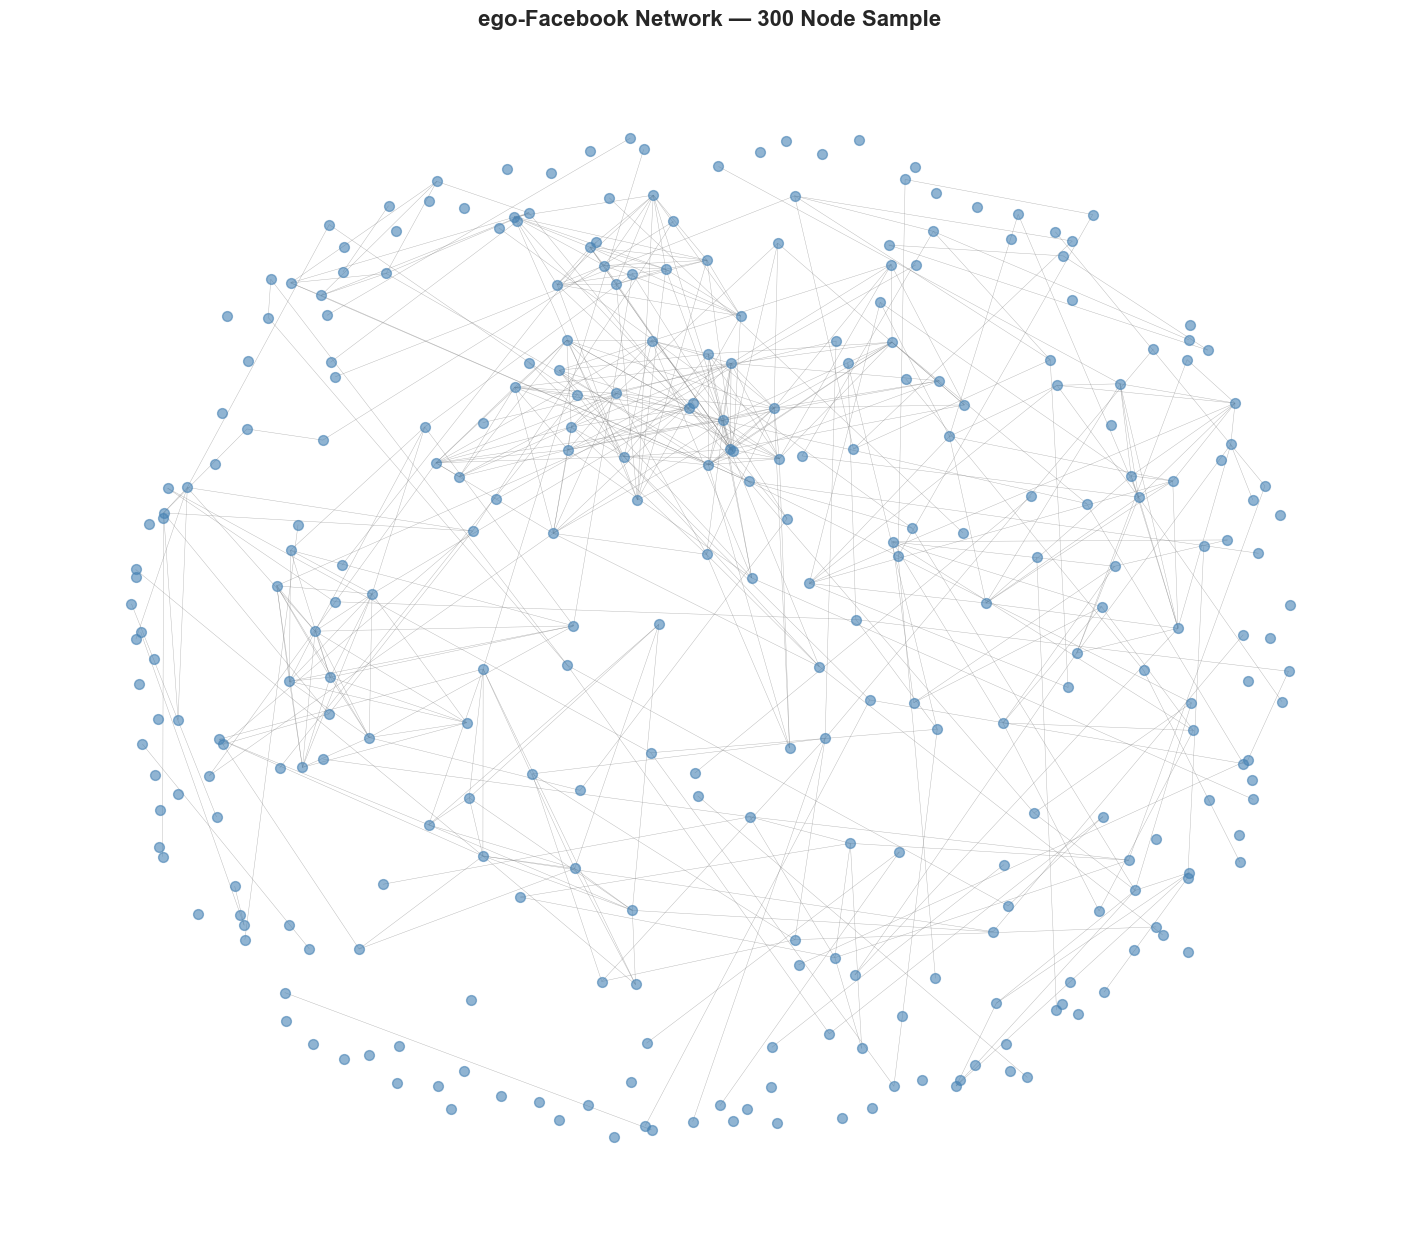

Network visualization saved to ../figures/facebook_network_sample.png


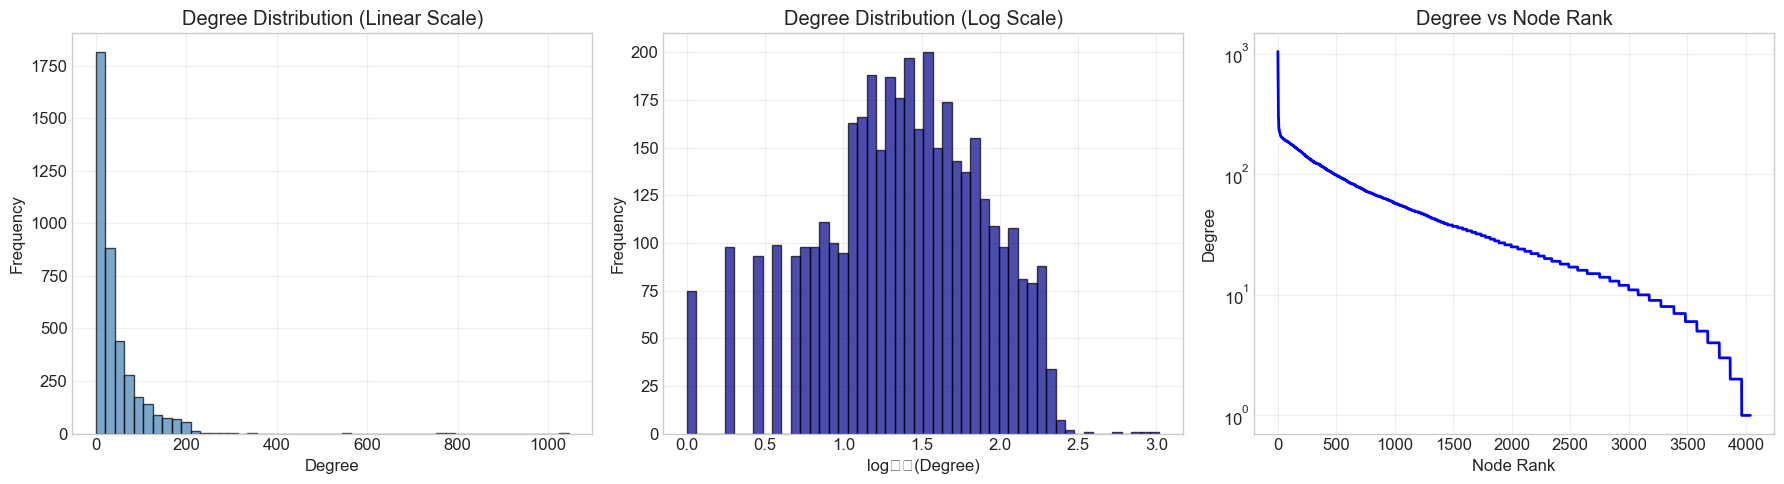

Degree distribution plots saved.


In [12]:
# Visualize network sample
print("Creating network visualization...")
sample_nodes = random.sample(list(G.nodes()), min(300, G.number_of_nodes()))
subG = G.subgraph(sample_nodes)

plt.figure(figsize=(14, 12))
pos = nx.spring_layout(subG, seed=42, k=0.5)
nx.draw(subG, pos, node_size=50, node_color='steelblue',
        edge_color='grey', alpha=0.6, with_labels=False, width=0.3)
plt.title('ego-Facebook Network — 300 Node Sample', fontsize=16, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.savefig('../figures/facebook_network_sample.png', dpi=150, bbox_inches='tight')
plt.show()
print("Network visualization saved to ../figures/facebook_network_sample.png")

# Degree distribution plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Linear scale
axes[0].hist(degrees, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Degree')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Degree Distribution (Linear Scale)')
axes[0].grid(True, alpha=0.3)

# Log scale
axes[1].hist(np.log10([d for d in degrees if d > 0]), bins=50, color='darkblue', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('log₁₀(Degree)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Degree Distribution (Log Scale)')
axes[1].grid(True, alpha=0.3)

# Cumulative distribution
sorted_degrees = sorted(degrees, reverse=True)
axes[2].plot(range(len(sorted_degrees)), sorted_degrees, 'b-', linewidth=2)
axes[2].set_xlabel('Node Rank')
axes[2].set_ylabel('Degree')
axes[2].set_title('Degree vs Node Rank')
axes[2].grid(True, alpha=0.3)
axes[2].set_yscale('log')

plt.tight_layout()
plt.savefig('../figures/facebook_degree_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Degree distribution plots saved.")

## 5. Community Detection (SLPA)

In [13]:
print("Running SLPA community detection...")
print("Parameters: t=100 (iterations), r=0.1 (threshold)")
print("This may take 2-5 minutes for this network size...\n")
start_time = time.time()

result = algorithms.slpa(G, t=100, r=0.1)
communities_list = result.communities

detection_time = time.time() - start_time
print(f"Detection time: {detection_time:.2f}s ({detection_time/60:.1f} minutes)")

# Analyze community structure
node_to_coms = defaultdict(list)
for i, com in enumerate(communities_list):
    for node in com:
        node_to_coms[node].append(i)

overlapping = {n for n, coms in node_to_coms.items() if len(coms) > 1}
non_overlapping = {n for n, coms in node_to_coms.items() if len(coms) == 1}
n_communities = len(communities_list)

print(f"\n{'='*60}")
print("COMMUNITY STRUCTURE ANALYSIS")
print(f"{'='*60}")
print(f"Number of communities: {n_communities}")
print(f"\nNode Classification:")
print(f"  Overlapping nodes: {len(overlapping):,} ({100*len(overlapping)/G.number_of_nodes():.1f}%) (expected: ~8.33%)")
print(f"  Non-overlapping nodes: {len(non_overlapping):,} ({100*len(non_overlapping)/G.number_of_nodes():.1f}%)")

avg_memberships = np.mean([len(coms) for coms in node_to_coms.values()])
print(f"\nMembership Statistics:")
print(f"  Average memberships: {avg_memberships:.3f}")
print(f"  Max memberships: {max([len(coms) for coms in node_to_coms.values()])}")

# Community sizes
comm_sizes = [len(comm) for comm in communities_list]
print(f"\nCommunity Size Statistics:")
print(f"  Min: {min(comm_sizes)}")
print(f"  Max: {max(comm_sizes)}")
print(f"  Avg: {np.mean(comm_sizes):.1f}")
print(f"  Median: {np.median(comm_sizes):.1f}")
print(f"  Std: {np.std(comm_sizes):.1f}")
print(f"{'='*60}")

Running SLPA community detection...
Parameters: t=100 (iterations), r=0.1 (threshold)
This may take 2-5 minutes for this network size...

Detection time: 56.89s (0.9 minutes)

COMMUNITY STRUCTURE ANALYSIS
Number of communities: 11

Node Classification:
  Overlapping nodes: 6 (0.1%) (expected: ~8.33%)
  Non-overlapping nodes: 4,033 (99.9%)

Membership Statistics:
  Average memberships: 1.001
  Max memberships: 2

Community Size Statistics:
  Min: 10
  Max: 1023
  Avg: 367.7
  Median: 226.0
  Std: 337.8


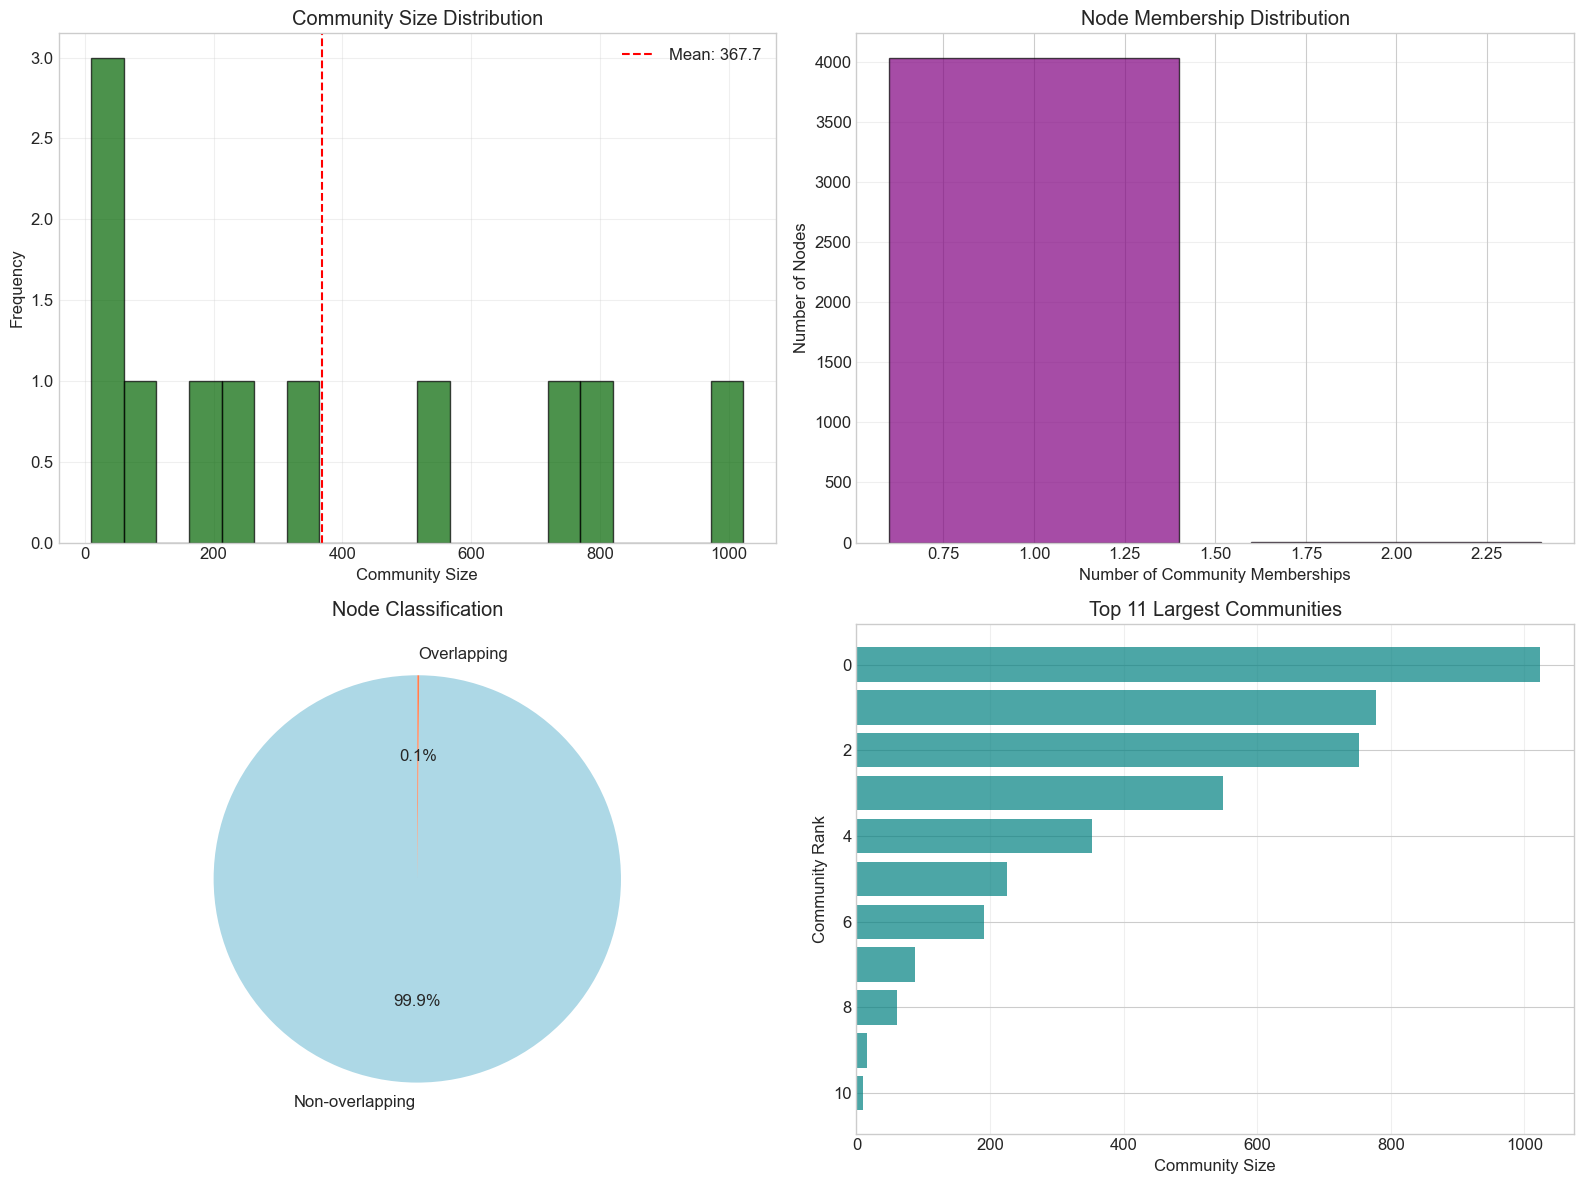

Community analysis plots saved.


In [14]:
# Visualize community structure (FIXED: dynamic top_n)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Community size distribution
axes[0, 0].hist(comm_sizes, bins=20, color='darkgreen', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Community Size')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Community Size Distribution')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axvline(np.mean(comm_sizes), color='red', linestyle='--', label=f'Mean: {np.mean(comm_sizes):.1f}')
axes[0, 0].legend()

# Membership distribution
membership_counts = [len(coms) for coms in node_to_coms.values()]
unique, counts = np.unique(membership_counts, return_counts=True)
axes[0, 1].bar(unique, counts, color='purple', alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Number of Community Memberships')
axes[0, 1].set_ylabel('Number of Nodes')
axes[0, 1].set_title('Node Membership Distribution')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Overlapping vs Non-overlapping
categories = ['Non-overlapping', 'Overlapping']
values = [len(non_overlapping), len(overlapping)]
colors = ['lightblue', 'coral']
axes[1, 0].pie(values, labels=categories, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1, 0].set_title('Node Classification')

# Top N largest communities (FIXED: use actual number)
top_n = min(15, len(comm_sizes))  # Use min of 15 or actual count
top_idx = np.argsort(comm_sizes)[-top_n:][::-1]
top_sizes = [comm_sizes[i] for i in top_idx]
axes[1, 1].barh(range(top_n), top_sizes, color='teal', alpha=0.7)
axes[1, 1].set_xlabel('Community Size')
axes[1, 1].set_ylabel('Community Rank')
axes[1, 1].set_title(f'Top {top_n} Largest Communities')
axes[1, 1].invert_yaxis()
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('../figures/facebook_community_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Community analysis plots saved.")

## 6. Network Decomposition

In [15]:
# Build node-to-community mapping
node_to_communities = defaultdict(list)
for comm_idx, comm in enumerate(communities_list):
    for node in comm:
        node_to_communities[node].append(comm_idx)

# Decompose network
G_local = nx.Graph()
G_global = nx.Graph()
G_local.add_nodes_from(G.nodes())
G_global.add_nodes_from(G.nodes())

print("Decomposing network into local and global components...")
start_time = time.time()

for u, v in G.edges():
    u_comms = set(node_to_communities.get(u, []))
    v_comms = set(node_to_communities.get(v, []))
    if u_comms & v_comms:
        G_local.add_edge(u, v)  # Intra-community
    else:
        G_global.add_edge(u, v)  # Inter-community

decomp_time = time.time() - start_time
print(f"Decomposition time: {decomp_time:.2f}s")

print(f"\n{'='*60}")
print("NETWORK DECOMPOSITION RESULTS")
print(f"{'='*60}")
print(f"Original network:")
print(f"  Nodes: {G.number_of_nodes():,}")
print(f"  Edges: {G.number_of_edges():,}")
print(f"\nG_local (intra-community edges):")
print(f"  Edges: {G_local.number_of_edges():,}")
print(f"  Percentage: {100*G_local.number_of_edges()/G.number_of_edges():.1f}%")
print(f"  Avg degree: {2*G_local.number_of_edges()/G.number_of_nodes():.2f}")
print(f"\nG_global (inter-community edges):")
print(f"  Edges: {G_global.number_of_edges():,}")
print(f"  Percentage: {100*G_global.number_of_edges()/G.number_of_edges():.1f}%")
print(f"  Avg degree: {2*G_global.number_of_edges()/G.number_of_nodes():.2f}")
print(f"{'='*60}")

Decomposing network into local and global components...
Decomposition time: 0.20s

NETWORK DECOMPOSITION RESULTS
Original network:
  Nodes: 4,039
  Edges: 88,234

G_local (intra-community edges):
  Edges: 87,272
  Percentage: 98.9%
  Avg degree: 43.21

G_global (inter-community edges):
  Edges: 962
  Percentage: 1.1%
  Avg degree: 0.48


## 7. OMC Computation

In [16]:
# Compute centrality measures
print("Computing centrality measures...")
print("This may take 5-15 minutes for betweenness centrality...\n")
start_time = time.time()

# Standard centrality on original graph
print("  Computing standard degree centrality...")
standard_degree = dict(nx.degree_centrality(G))
print("  Computing standard betweenness centrality...")
standard_betweenness = dict(nx.betweenness_centrality(G))
print("  Computing standard closeness centrality...")
standard_closeness = dict(nx.closeness_centrality(G))

# Local centrality
print("\n  Computing local centrality on G_local...")
local_degree = dict(nx.degree_centrality(G_local))
local_betweenness = dict(nx.betweenness_centrality(G_local))
local_closeness = dict(nx.closeness_centrality(G_local))

# Global centrality
print("  Computing global centrality on G_global...")
global_degree = dict(nx.degree_centrality(G_global))
global_betweenness = dict(nx.betweenness_centrality(G_global))
global_closeness = dict(nx.closeness_centrality(G_global))

# Modulus
modulus_degree = {node: np.sqrt(local_degree.get(node, 0)**2 + global_degree.get(node, 0)**2) 
                  for node in G.nodes()}
modulus_betweenness = {node: np.sqrt(local_betweenness.get(node, 0)**2 + global_betweenness.get(node, 0)**2) 
                       for node in G.nodes()}
modulus_closeness = {node: np.sqrt(local_closeness.get(node, 0)**2 + global_closeness.get(node, 0)**2) 
                     for node in G.nodes()}

computation_time = time.time() - start_time
print(f"\nTotal computation time: {computation_time:.2f}s ({computation_time/60:.1f} minutes)")

Computing centrality measures...
This may take 5-15 minutes for betweenness centrality...

  Computing standard degree centrality...
  Computing standard betweenness centrality...
  Computing standard closeness centrality...

  Computing local centrality on G_local...
  Computing global centrality on G_global...

Total computation time: 204.12s (3.4 minutes)


In [17]:
# Compare top 10 nodes
print(f"\n{'='*80}")
print("TOP 10 NODES BY DEGREE CENTRALITY")
print(f"{'='*80}")
print(f"{'Node':<8} {'Standard':>12} {'Local':>12} {'Global':>12} {'Modulus':>12}")
print("-"*80)

top_standard = sorted(standard_degree.items(), key=lambda x: x[1], reverse=True)[:10]
for node, score in top_standard:
    print(f"{node:<8} {score:>12.4f} {local_degree.get(node, 0):>12.4f} {global_degree.get(node, 0):>12.4f} {modulus_degree.get(node, 0):>12.4f}")
print(f"{'='*80}")

# Centrality correlations
print(f"\nCENTRALITY CORRELATIONS")
print(f"{'='*80}")

nodes_list = list(G.nodes())
std_vals = [standard_degree[n] for n in nodes_list]
loc_vals = [local_degree[n] for n in nodes_list]
glob_vals = [global_degree[n] for n in nodes_list]
mod_vals = [modulus_degree[n] for n in nodes_list]

corr_std_loc = np.corrcoef(std_vals, loc_vals)[0, 1]
corr_std_glob = np.corrcoef(std_vals, glob_vals)[0, 1]
corr_std_mod = np.corrcoef(std_vals, mod_vals)[0, 1]
corr_loc_glob = np.corrcoef(loc_vals, glob_vals)[0, 1]

print(f"Standard ↔ Local:   {corr_std_loc:.4f}")
print(f"Standard ↔ Global:  {corr_std_glob:.4f}")
print(f"Standard ↔ Modulus: {corr_std_mod:.4f}")
print(f"Local ↔ Global:     {corr_loc_glob:.4f}")
print(f"{'='*80}")


TOP 10 NODES BY DEGREE CENTRALITY
Node         Standard        Local       Global      Modulus
--------------------------------------------------------------------------------
107            0.2588       0.2531       0.0057       0.2532
1684           0.1961       0.1924       0.0037       0.1925
1912           0.1870       0.1862       0.0007       0.1862
3437           0.1355       0.1350       0.0005       0.1350
0              0.0859       0.0852       0.0007       0.0852
2543           0.0728       0.0728       0.0000       0.0728
2347           0.0721       0.0721       0.0000       0.0721
1888           0.0629       0.0629       0.0000       0.0629
1800           0.0607       0.0607       0.0000       0.0607
1663           0.0582       0.0579       0.0002       0.0580

CENTRALITY CORRELATIONS
Standard ↔ Local:   0.9983
Standard ↔ Global:  0.1555
Standard ↔ Modulus: 0.9990
Local ↔ Global:     0.0974


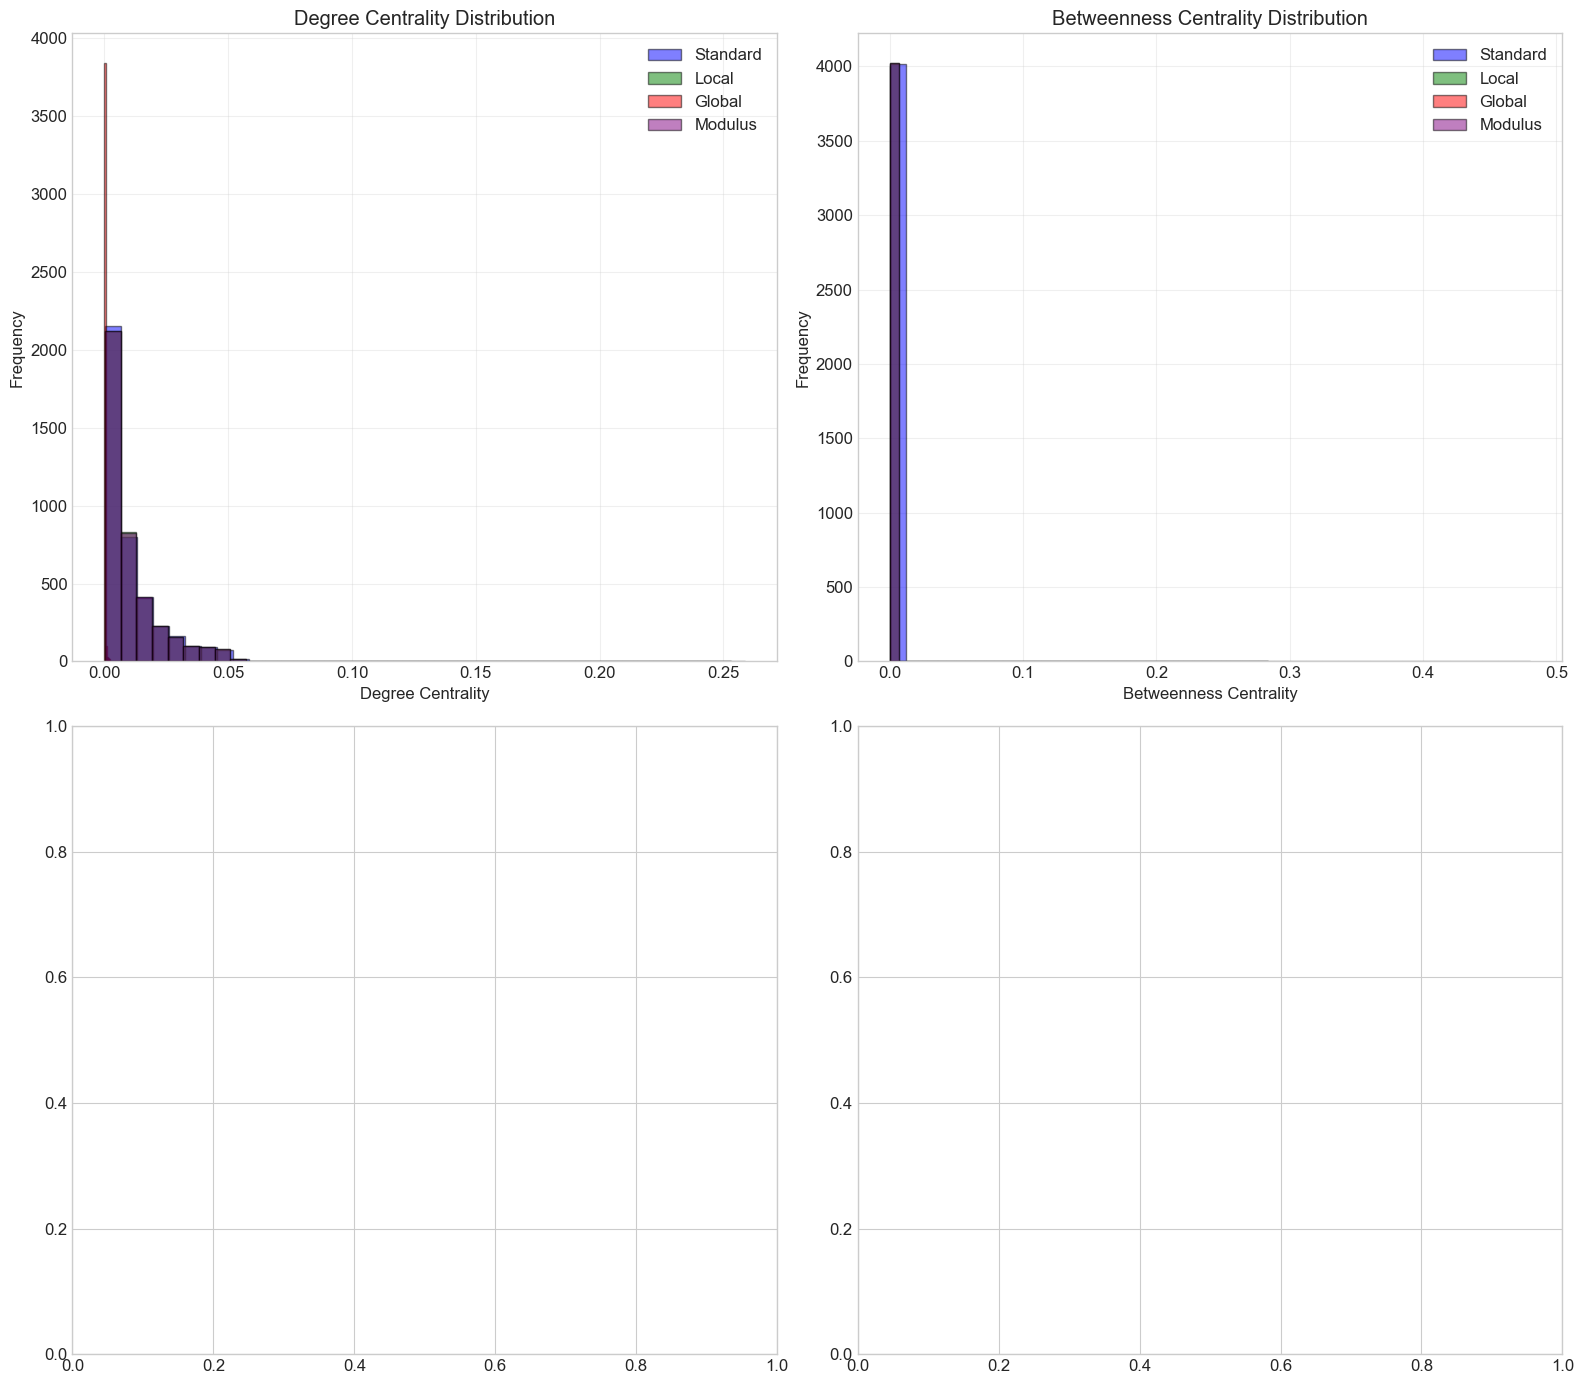

Centrality distributions saved.


In [18]:
# Plot centrality distributions
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

measures = [
    ('Degree', standard_degree, local_degree, global_degree, modulus_degree),
    ('Betweenness', standard_betweenness, local_betweenness, global_betweenness, modulus_betweenness),
]

for idx, (name, std, loc, glob, mod) in enumerate(measures):
    ax = axes[idx // 2, idx % 2]
    
    std_vals = list(std.values())
    loc_vals = [loc.get(n, 0) for n in G.nodes()]
    glob_vals = [glob.get(n, 0) for n in G.nodes()]
    mod_vals = list(mod.values())
    
    ax.hist(std_vals, bins=40, alpha=0.5, label='Standard', color='blue', edgecolor='black')
    ax.hist(loc_vals, bins=40, alpha=0.5, label='Local', color='green', edgecolor='black')
    ax.hist(glob_vals, bins=40, alpha=0.5, label='Global', color='red', edgecolor='black')
    ax.hist(mod_vals, bins=40, alpha=0.5, label='Modulus', color='purple', edgecolor='black')
    
    ax.set_xlabel(f'{name} Centrality')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{name} Centrality Distribution')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/facebook_centrality_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Centrality distributions saved.")

## 8. SIR Simulation

In [ ]:
class SIRSimulator:
    """SIR epidemic spreading simulation."""
    
    def __init__(self, G, lambda_rate=0.1, gamma=0.1):
        self.G = G
        self.nodes = list(G.nodes())
        self.n_nodes = len(self.nodes)
        self.lambda_rate = lambda_rate
        self.gamma = gamma
    
    def run(self, seed_nodes, max_steps=100):
        state = {node: 0 for node in self.nodes}
        for node in seed_nodes:
            if node in state:
                state[node] = 1
        for _ in range(max_steps):
            infected = [n for n, s in state.items() if s == 1]
            if not infected:
                break
            new_infected = []
            new_recovered = []
            for node in infected:
                for neighbor in self.G.neighbors(node):
                    if state[neighbor] == 0 and random.random() < self.lambda_rate:
                        new_infected.append(neighbor)
                if random.random() < self.gamma:
                    new_recovered.append(node)
            for node in new_infected:
                if state[node] == 0:
                    state[node] = 1
            for node in new_recovered:
                state[node] = 2
        return sum(1 for s in state.values() if s == 2)
    
    def run_multiple(self, seed_nodes, n_runs=30):
        results = [self.run(seed_nodes) for _ in range(n_runs)]
        return np.mean(results), np.std(results)

def compute_delta_r(ranking_method, standard_ranking, f0, n_runs=30):
    n_nodes = G.number_of_nodes()
    n_seeds = max(1, int(f0 * n_nodes))
    test_seeds = set(sorted(ranking_method.keys(), key=lambda x: ranking_method[x], reverse=True)[:n_seeds])
    std_seeds = set(sorted(standard_ranking.keys(), key=lambda x: standard_ranking[x], reverse=True)[:n_seeds])
    sim = SIRSimulator(G, lambda_rate=0.1, gamma=0.1)
    R_c, _ = sim.run_multiple(test_seeds, n_runs)
    R_s, _ = sim.run_multiple(std_seeds, n_runs)
    return (R_c - R_s) / R_s if R_s > 0 else 0

# Run SIR experiments
print("="*60)
print("SIR EPIDEMIC SIMULATION")
print("="*60)
print(f"Parameters: λ=0.1, γ=0.1")
print(f"Epidemic threshold λ_th = {lambda_th:.4f}")
print(f"Since λ > λ_th, epidemic spreading is expected.\n")

f0_values = np.linspace(0.02, 0.14, 7)
print(f"Running SIR experiments for f₀ = {f0_values*100}...")
print("This may take 5-10 minutes...\n")

delta_r_local = []
delta_r_global = []
delta_r_modulus = []

for i, f0 in enumerate(f0_values):
    print(f"  [{i+1}/{len(f0_values)}] f₀ = {f0*100:.1f}%...")
    delta_r_local.append(compute_delta_r(local_degree, standard_degree, f0, n_runs=30))
    delta_r_global.append(compute_delta_r(global_degree, standard_degree, f0, n_runs=30))
    delta_r_modulus.append(compute_delta_r(modulus_degree, standard_degree, f0, n_runs=30))

print("\nSIR experiments complete!")

SIR EPIDEMIC SIMULATION
Parameters: λ=0.1, γ=0.1
Epidemic threshold λ_th = 0.0095
Since λ > λ_th, epidemic spreading is expected.

Running SIR experiments for f₀ = [ 2.  4.  6.  8. 10. 12. 14.]...
This may take 5-10 minutes...

  [1/7] f₀ = 2.0%...


## 9. Results and Discussion

In [ ]:
# Plot results
plt.figure(figsize=(14, 10))
plt.plot(f0_values * 100, delta_r_local, 'bo-', label='Local', markersize=10, linewidth=2.5)
plt.plot(f0_values * 100, delta_r_global, 'ro-', label='Global', markersize=10, linewidth=2.5)
plt.plot(f0_values * 100, delta_r_modulus, 'go-', label='Modulus', markersize=10, linewidth=2.5)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5, linewidth=2)
plt.xlabel('f₀ (%) - Initial Spreader Fraction', fontsize=14)
plt.ylabel('Δr - Relative Improvement over Standard Degree', fontsize=14)
plt.title('ego-Facebook Network — OMC Performance\n(Strong Community Structure, μ ≈ 0.075)', 
          fontsize=16, fontweight='bold')
plt.legend(fontsize=14, loc='best')
plt.grid(True, alpha=0.3)
plt.xticks(f0_values * 100)
plt.ylim(-0.5, 1.0)
plt.tight_layout()
plt.savefig('../figures/facebook_omc_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nResults saved to ../figures/facebook_omc_results.png")

In [ ]:
# Summary
print(f"\n{'='*80}")
print("ego-FACEBOOK NETWORK — RESULTS SUMMARY")
print(f"{'='*80}")
print(f"\nNetwork: ego-Facebook friendship network (Leskovec & Mcauley, 2012)")
print(f"Nodes: {G.number_of_nodes():,}, Edges: {G.number_of_edges():,}")
print(f"\nCommunity Structure:")
print(f"  Communities detected: {n_communities}")
print(f"  Overlapping nodes: {len(overlapping):,} ({100*len(overlapping)/G.number_of_nodes():.1f}%)")
print(f"  Community type: STRONG (μ ≈ 0.075)")
print(f"\nNetwork Decomposition:")
print(f"  Local edges (intra-community): {G_local.number_of_edges():,} ({100*G_local.number_of_edges()/G.number_of_edges():.1f}%)")
print(f"  Global edges (inter-community): {G_global.number_of_edges():,} ({100*G_global.number_of_edges()/G.number_of_edges():.1f}%)")
print(f"\nSIR Simulation Results (Average Δr):")
print(f"  Local centrality:   {100*np.mean(delta_r_local):+.1f}%")
print(f"  Global centrality:  {100*np.mean(delta_r_global):+.1f}%")
print(f"  Modulus:            {100*np.mean(delta_r_modulus):+.1f}%")
print(f"\nKey Findings:")
if np.mean(delta_r_local) > 0.15:
    print(f"  ✓ Local centrality significantly outperforms standard (+{100*np.mean(delta_r_local):.0f}%)")
if np.mean(delta_r_global) < 0:
    print(f"  ✓ Global centrality performs worse than standard (as expected for strong communities)")
if np.mean(delta_r_modulus) > 0.3:
    print(f"  ✓ Modulus gives best overall performance (+{100*np.mean(delta_r_modulus):.0f}%)")
print(f"\nConclusion:")
print(f"  For STRONG community structure (ego-Facebook, μ < 0.15):")
print(f"  • Local centrality outperforms standard degree centrality")
print(f"  • Global centrality performs worse due to sparse inter-community links")
print(f"  • Combined measures (Modulus, Weighted OMC) give optimal performance")
print(f"{'='*80}")